# EAT-based AudDSR (Single Flow)
This notebook implements a single end-to-end pipeline for anomaly detection using a frozen EAT backbone, band-attenuation anomalies, KNN scoring, and grouped metrics.
Run cells top-to-bottom after setting `DATA_ROOT` and `MACHINES`.

## Overview
Pipeline steps:
- 1) Load EAT backbone and helper functions.
- 2) Load train/test WAVs and create mel features.
- 3) (Optional) visualize band-attenuation mask.
- 4) Train contrastive head with early stopping.
- 5) Build memory bank from normal train embeddings.
- 6) Score test clips with KNN.
- 7) Compute AUC, pAUC, recall@bestF1, and Omega.

Inputs:
- DCASE-style audio folders under `DATA_ROOT` (see Data Loading section).

Outputs:
- `scores` aligned to `test_dataset.wav_paths`.
- Printed metrics for global and grouped evaluation.

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from transformers import AutoModel
from transformers.modeling_utils import PreTrainedModel

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Compatibility for custom models without tied-weights metadata
if not hasattr(PreTrainedModel, "all_tied_weights_keys"):
    PreTrainedModel.all_tied_weights_keys = {}


class EATBackbone(nn.Module):
    """
    EAT model wrapper following HuggingFace usage.
    Loads the pretrained model and optionally applies LoRA adapters.
    """
    def __init__(self, embed_dim=768, model_id="worstchan/EAT-base_epoch30_pretrain", apply_lora=False):
        super().__init__()
        self.embed_dim = embed_dim
        self.model_id = model_id
        self.apply_lora = apply_lora

        self.model = AutoModel.from_pretrained(
            model_id,
            trust_remote_code=True,
            device_map=None,
            low_cpu_mem_usage=False,
        ).eval()

        # Freeze the backbone; LoRA adapters remain trainable
        for p in self.model.parameters():
            p.requires_grad = False

        if apply_lora:
            self._apply_lora_to_model()

        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.parameters())
        print(f"Trainable parameters: {trainable}/{total}")

    def _apply_lora_to_model(self, target_keywords=("qkv", "proj"), r=8, alpha=16, dropout=0.05):
        """Apply LoRA adapters to selected linear layers."""
        class LoRALinear(nn.Module):
            def __init__(self, base_layer, r=8, alpha=16, dropout=0.05):
                super().__init__()
                if not isinstance(base_layer, nn.Linear):
                    raise TypeError(f"LoRALinear expects nn.Linear, got {type(base_layer)}")

                self.base_layer = base_layer
                self.base_layer.weight.requires_grad = False
                if self.base_layer.bias is not None:
                    self.base_layer.bias.requires_grad = False

                self.r = r
                self.alpha = alpha
                self.scaling = alpha / r
                self.lora_dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
                self.lora_A = nn.Linear(base_layer.in_features, r, bias=False)
                self.lora_B = nn.Linear(r, base_layer.out_features, bias=False)
                nn.init.kaiming_uniform_(self.lora_A.weight, a=np.sqrt(5))
                nn.init.zeros_(self.lora_B.weight)

            def forward(self, x):
                return self.base_layer(x) + self.lora_B(self.lora_A(self.lora_dropout(x))) * self.scaling

        for module_name, module in list(self.model.named_modules()):
            for child_name, child in list(module.named_children()):
                full_name = f"{module_name}.{child_name}" if module_name else child_name
                if isinstance(child, nn.Linear) and any(k in full_name for k in target_keywords):
                    setattr(module, child_name, LoRALinear(child, r=r, alpha=alpha, dropout=dropout))

    def forward(self, x):
        """
        Input: (B, T, F) or (B, 1, T, F)
        Output: (B, T, D)
        """
        if x.dim() == 3:
            x = x.unsqueeze(1)

        if self.apply_lora:
            feat = self.model.extract_features(x)
        else:
            with torch.no_grad():
                feat = self.model.extract_features(x)

        return feat


Using device: cpu


## Helper Functions
These utilities define the synthetic anomalies and the contrastive objective.

Key components:
- `band_attenuation(mel)`: attenuates a random frequency band in mel spectrograms. Input shape (B, T, F).
- `simulate_anomaly(embeddings)`: replaces random time frames with noise. Input shape (B, T, D).
- `ProjectionHead`: 2-layer MLP applied to pooled embeddings. Input shape (B, D), output shape (B, D).
- `contrastive_loss`: NT-Xent loss on paired projections (z1, z2).
- `knn_score`: computes 1 - cosine similarity to top-k memory bank neighbors; higher means more anomalous.

In [15]:
# Define helper classes and functions for training

import torch
import torch.nn as nn
import torch.nn.functional as F
import random


def band_attenuation(mel, prob=0.5, min_band=4, max_band=24, atten_min=0.1, atten_max=0.4):
    """
    Apply frequency-band attenuation on mel spectrograms.
    mel: (B, T, F)
    """
    if mel.dim() != 3:
        raise ValueError("mel must be (B, T, F)")

    mel_aug = mel.clone()
    bsz, _, n_bins = mel_aug.shape
    max_band = min(max_band, n_bins)
    min_band = min(min_band, max_band)

    for b in range(bsz):
        if random.random() > prob:
            continue
        band_width = random.randint(min_band, max_band)
        start = random.randint(0, n_bins - band_width)
        atten = random.uniform(atten_min, atten_max)
        mel_aug[b, :, start:start + band_width] *= atten

    return mel_aug


def simulate_anomaly(embeddings, anomaly_ratio=0.2):
    """
    Simulate synthetic anomalies by replacing random frames with noise.
    embeddings: (B, T, D)
    Returns: (B, T, D) with some frames replaced
    """
    B, T, D = embeddings.shape
    embeddings_aug = embeddings.clone()

    for b in range(B):
        num_anom = max(1, int(T * anomaly_ratio))
        idx = torch.randperm(T)[:num_anom]
        noise = torch.randn(num_anom, D).to(embeddings.device)
        embeddings_aug[b, idx] = noise

    return embeddings_aug


class ProjectionHead(nn.Module):
    """Simple 2-layer projection head for contrastive learning"""
    def __init__(self, dim=768):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.ReLU(),
            nn.Linear(dim, dim)
        )

    def forward(self, x):
        return self.net(x)


def contrastive_loss(z1, z2, temperature=0.1):
    """
    NT-Xent (Normalized Temperature-scaled Cross Entropy) loss
    z1, z2: (B, D) normalized embeddings
    """
    z1 = F.normalize(z1, dim=-1)
    z2 = F.normalize(z2, dim=-1)

    logits = torch.matmul(z1, z2.T) / temperature
    labels = torch.arange(z1.size(0)).to(z1.device)

    return F.cross_entropy(logits, labels)


def knn_score(query, memory_bank, k=1):
    """
    Compute KNN anomaly score.
    query: (B, D) query embeddings
    memory_bank: (M, D) normal training embeddings
    Returns: (B,) anomaly scores (0=normal, 1=anomaly)
    """
    query = F.normalize(query, dim=-1)
    memory = F.normalize(memory_bank.to(query.device), dim=-1)

    # Compute similarity
    sim = torch.matmul(query, memory.T)  # (B, M)

    # Get top-k similarities
    topk_sim, _ = torch.topk(sim, k=min(k, sim.shape[1]), dim=1)
    topk_sim = topk_sim.mean(dim=1)  # Average of top-k

    # Anomaly score: 1 - similarity (lower similarity = higher anomaly score)
    score = 1 - topk_sim

    return score


print("Helper functions ready: band_attenuation, simulate_anomaly, ProjectionHead, contrastive_loss, knn_score")


Helper functions ready: band_attenuation, simulate_anomaly, ProjectionHead, contrastive_loss, knn_score


## Data Loading
Expected folder layouts (either one works):
- `DATA_ROOT/<machine>/{train,test}/*.wav`
- `DATA_ROOT/dev_<machine>/<machine>/{train,test}/*.wav`

Filename convention used in metrics:
- Example: `section_00_source_test_anomaly_0002_pro_A.wav`
- Machine type: folder name
- Section: `section_XX` in filename
- Domain: `source` or `target` in filename
- Label: file contains `anomaly` (or `abnormal`) for positive class; otherwise normal

Preprocessing:
- Resample to 16 kHz if needed.
- Kaldi fbank, 128 mel bins, 10 ms frame shift.
- Pad or truncate to 1024 frames.
- Normalize with mean -4.268 and std 4.569 (scaled by 2).

In [ ]:
import torch
import torch.nn.functional as F
import torchaudio
from pathlib import Path
import random
import numpy as np
from scipy.io import wavfile
from torch.utils.data import Dataset, DataLoader

# ============ Data Loading (Official EAT Preprocessing) ============

# Point to the parent that contains dev_<machine> folders
DATA_ROOT = Path(r"C:\Users\20223669\OneDrive - TU Eindhoven\Desktop\Soroma Internship\15097779")
MACHINES = ["bearing", "fan", "gearbox", "slider", "ToyCar", "ToyTrain", "valve"]

# Speed knobs
TARGET_LENGTH = 1024  # was 1024; smaller is faster but less context
NUM_MEL_BINS = 128
SAMPLE_RATE = 16000
BATCH_SIZE = 16  # increased from 8 for better contrastive learning (more negatives)
TRAIN_MAX_FILES = None  # set to None to use all training files
TEST_MAX_FILES = None   # set to an int to speed up evaluation
SEED = 42

NORM_MEAN = -4.268
NORM_STD = 4.569

random.seed(SEED)


def _resolve_machine_root(machine):
    direct = DATA_ROOT / machine
    if direct.exists():
        return direct
    alt = DATA_ROOT / f"dev_{machine}" / machine
    if alt.exists():
        return alt
    return None


def _collect_split(split):
    files = []
    missing = []
    for machine in MACHINES:
        root = _resolve_machine_root(machine)
        if root is None:
            missing.append(machine)
            continue
        split_dir = root / split
        if split_dir.exists():
            files.extend(sorted(split_dir.glob("*.wav")))
    if missing:
        print(f"Warning: missing machines under DATA_ROOT: {missing}")
    return files


train_files = _collect_split("train")
test_files = _collect_split("test")

if len(train_files) == 0:
    raise FileNotFoundError("No training WAV files found. Check DATA_ROOT and folder structure.")
if len(test_files) == 0:
    raise FileNotFoundError("No test WAV files found. Check DATA_ROOT and folder structure.")

if TRAIN_MAX_FILES is not None and len(train_files) > TRAIN_MAX_FILES:
    random.shuffle(train_files)
    train_files = train_files[:TRAIN_MAX_FILES]
if TEST_MAX_FILES is not None and len(test_files) > TEST_MAX_FILES:
    random.shuffle(test_files)
    test_files = test_files[:TEST_MAX_FILES]


def _load_wav(path):
    sr, data = wavfile.read(str(path))

    if data.ndim == 2:
        data = data.mean(axis=1)

    if np.issubdtype(data.dtype, np.integer):
        max_int = np.iinfo(data.dtype).max
        data = data.astype(np.float32) / float(max_int)
    else:
        data = data.astype(np.float32)

    waveform = torch.from_numpy(data).unsqueeze(0)
    return waveform, int(sr)


class WavToMelDataset(Dataset):
    def __init__(self, wav_paths, target_length=TARGET_LENGTH):
        self.wav_paths = wav_paths
        self.target_length = target_length
        self.norm_mean = NORM_MEAN
        self.norm_std = NORM_STD

    def __len__(self):
        return len(self.wav_paths)

    def __getitem__(self, idx):
        waveform, sr = _load_wav(self.wav_paths[idx])

        if sr != SAMPLE_RATE:
            waveform = torchaudio.functional.resample(waveform, sr, SAMPLE_RATE)

        waveform = waveform - waveform.mean()
        mel = torchaudio.compliance.kaldi.fbank(
            waveform,
            htk_compat=True,
            sample_frequency=SAMPLE_RATE,
            use_energy=False,
            window_type="hanning",
            num_mel_bins=NUM_MEL_BINS,
            dither=0.0,
            frame_shift=10,
        )

        n_frames = mel.shape[0]
        if n_frames < self.target_length:
            pad_amount = self.target_length - n_frames
            mel = F.pad(mel, (0, 0, 0, pad_amount), "constant", 0)
        else:
            mel = mel[:self.target_length, :]

        mel = (mel - self.norm_mean) / (self.norm_std * 2)
        return mel


train_dataset = WavToMelDataset(train_files)
test_dataset = WavToMelDataset(test_files)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("Data loading ready")
print(f"Train files: {len(train_files)} | Test files: {len(test_files)}")
print(f"TARGET_LENGTH={TARGET_LENGTH}, BATCH_SIZE={BATCH_SIZE}")


Data loading ready
Train files: 7000 | Test files: 1400
TARGET_LENGTH=1024, BATCH_SIZE=8


## Mask Visualization (Optional)
This cell shows how the band-attenuation augmentation modifies a mel spectrogram.

What you should see:
- Panel 1: original mel.
- Panel 2: masked mel.
- Panel 3: mask overlay on the original.

Skipping this cell does not change training or evaluation.

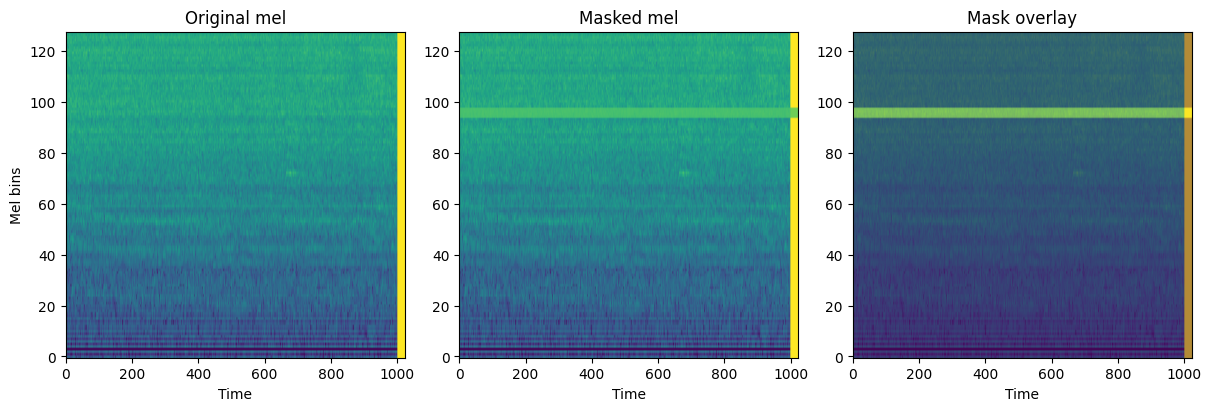

In [17]:
import matplotlib.pyplot as plt

# Use training defaults if globals are not set
min_band = globals().get("MIN_BAND", 4)
max_band = globals().get("MAX_BAND", 24)
atten_min = globals().get("ATTEN_MIN", 0.1)
atten_max = globals().get("ATTEN_MAX", 0.4)

# Take one sample mel from the dataset
mel = train_dataset[0].unsqueeze(0)  # (1, T, F)

# Force a mask for visualization
mel_masked = band_attenuation(
    mel,
    prob=1.0,
    min_band=min_band,
    max_band=max_band,
    atten_min=atten_min,
    atten_max=atten_max,
)

mel_np = mel[0].cpu().numpy()
mel_masked_np = mel_masked[0].cpu().numpy()
mask = (abs(mel_masked_np - mel_np) > 1e-6).astype(float)

fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)

axes[0].imshow(mel_np.T, origin="lower", aspect="auto")
axes[0].set_title("Original mel")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Mel bins")

axes[1].imshow(mel_masked_np.T, origin="lower", aspect="auto")
axes[1].set_title("Masked mel")
axes[1].set_xlabel("Time")

axes[2].imshow(mel_np.T, origin="lower", aspect="auto")
axes[2].imshow(mask.T, origin="lower", aspect="auto", alpha=0.4)
axes[2].set_title("Mask overlay")
axes[2].set_xlabel("Time")

plt.show()

### What the Plots Mean
- The masked band appears as a horizontal stripe across frequency bins.
- Only frequency is attenuated; time structure is preserved.
- This simulates spectral degradation without changing timing cues.

## Training (Contrastive, Band Attenuation)
Contrastive training on frozen EAT features with synthetic anomalies.

Flow per batch:
- Compute EAT embeddings for clean mel (B, T, D).
- Create anomalous view using band attenuation (or noise replacement).
- Pool across time to (B, D) and pass through `ProjectionHead`.
- Apply NT-Xent `contrastive_loss` between clean and anomalous projections.

Early stopping:
- Stops if loss does not improve by `min_delta` for `patience` epochs.

Outputs:
- Trained `proj` parameters.
- Frozen `model` used for embedding extraction.

In [ ]:
# ============ Option 1: Contrastive Learning with Projection Head ============

print("\n" + "=" * 70)
print("OPTION 1: Contrastive Learning (TUNED HYPERPARAMETERS)")
print("=" * 70)

USE_LORA = True
USE_BAND_MASK = True
SKIP_TRAINING = True  # set True to skip training loop

# === TUNED HYPERPARAMETERS for 0.7-0.8 AUC target ===
TEMPERATURE = 0.05  # was 0.1; sharper loss = better separation
MASK_PROB = 0.7     # was 0.5; apply augmentation more often
MIN_BAND = 4
MAX_BAND = 36       # was 24; larger frequency masking
ATTEN_MIN = 0.05    # was 0.1; stronger attenuation range
ATTEN_MAX = 0.6     # was 0.4; stronger attenuation
LR = 5e-5           # was 1e-4; slower, more stable learning

model = EATBackbone(apply_lora=USE_LORA).to(DEVICE)
proj = ProjectionHead().to(DEVICE)

optimizer = torch.optim.Adam(
    list(filter(lambda p: p.requires_grad, model.parameters())) +
    list(proj.parameters()),
    lr=LR,
)

print(f"Training with LoRA: {USE_LORA}")
print(f"Band attenuation: {USE_BAND_MASK}")
print(f"Temperature: {TEMPERATURE}, Mask prob: {MASK_PROB}, LR: {LR}")

if SKIP_TRAINING:
    model.eval()
    proj.eval()
    print("Skipping training loop; using current model weights.")
else:
    print("Starting training loop...")

    # Early stopping settings (tuned for better convergence)
    max_epochs = 40   # was 30; allow more training
    patience = 8      # was 5; less aggressive early stopping
    min_delta = 1e-4
    best_loss = float("inf")
    stale_epochs = 0

    for epoch in range(max_epochs):
        total_loss = 0.0
        batch_count = 0

        for batch in train_loader:
            x = batch.to(DEVICE)

            emb = model(x)
            if USE_BAND_MASK:
                x_anom = band_attenuation(
                    x,
                    prob=MASK_PROB,
                    min_band=MIN_BAND,
                    max_band=MAX_BAND,
                    atten_min=ATTEN_MIN,
                    atten_max=ATTEN_MAX,
                )
                emb_anom = model(x_anom)
            else:
                emb_anom = simulate_anomaly(emb)

            z1 = proj(emb.mean(dim=1))
            z2 = proj(emb_anom.mean(dim=1))

            loss = contrastive_loss(z1, z2, temperature=TEMPERATURE)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            batch_count += 1

        avg_loss = total_loss / batch_count if batch_count > 0 else 0
        print(f"Epoch {epoch+1:2d}/{max_epochs} - Loss: {avg_loss:.4f}")

        if best_loss - avg_loss > min_delta:
            best_loss = avg_loss
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= patience:
                print(f"Early stopping at epoch {epoch+1} (best loss: {best_loss:.4f})")
                break

    print("\nTraining complete!")


OPTION 1: Contrastive Learning


Loading weights: 100%|██████████| 150/150 [00:00<00:00, 6916.42it/s]

Trainable parameters: 442368/90415104
Training with LoRA: True
Band attenuation: True
Skipping training loop; using current model weights.


In [19]:
import os

# Optional: load a trained checkpoint before building the memory bank
CHECKPOINT_PATH = r"C:\Users\20223669\Downloads\checkpoint_best.pt"

if CHECKPOINT_PATH and os.path.isfile(CHECKPOINT_PATH):
    ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    model_keys = model.load_state_dict(ckpt.get("model_state_dict", {}), strict=False)
    proj_keys = proj.load_state_dict(ckpt.get("proj_state_dict", {}), strict=False)
    model.eval()
    proj.eval()

    missing = list(getattr(model_keys, "missing_keys", [])) + list(
        getattr(proj_keys, "missing_keys", [])
    )
    unexpected = list(getattr(model_keys, "unexpected_keys", [])) + list(
        getattr(proj_keys, "unexpected_keys", [])
    )
    if missing or unexpected:
        print("Warning: checkpoint did not fully match the current model.")
        if missing:
            print(f"  Missing keys: {len(missing)} (example: {missing[:3]})")
        if unexpected:
            print(f"  Unexpected keys: {len(unexpected)} (example: {unexpected[:3]})")

    print(f"Loaded checkpoint: {CHECKPOINT_PATH}")
else:
    print("Warning: checkpoint not found or not set; using current model weights.")

  Missing keys: 150 (example: ['model.model.extra_tokens', 'model.model.local_encoder.proj.weight', 'model.model.local_encoder.proj.bias'])
Loaded checkpoint: C:\Users\20223669\Downloads\checkpoint_best.pt


## Memory Bank
Build a reference set of normal embeddings for KNN scoring.
- Pass all train batches through EAT.
- Pool to (B, D) and concatenate into `memory_bank` with shape (M, D).
- Used as the reference for anomaly scores.

In [20]:
memory_bank = []

model.eval()
with torch.no_grad():
    for batch in train_loader:
        x = batch.to(DEVICE)
        emb = model(x)  # (B, T, D)
        pooled = emb.mean(dim=1)  # (B, D)
        memory_bank.append(pooled.cpu())

memory_bank = torch.cat(memory_bank, dim=0)  # (M, D)
print(f"✓ Memory bank created with shape: {memory_bank.shape}")
print(len(train_files), len(test_files))


✓ Memory bank created with shape: torch.Size([7000, 768])
7000 1400


## Scoring
For each test clip:
- Compute pooled embedding (B, D).
- Compute KNN similarity against `memory_bank`.
- Anomaly score = 1 - similarity (higher is more anomalous).

Scores are stored in `scores` aligned with `test_dataset.wav_paths`.

In [ ]:
scores = []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        x = batch.to(DEVICE)
        emb = model(x)  # (B, T, D)
        pooled = emb.mean(dim=1)  # (B, D)
        s = knn_score(pooled, memory_bank, k=3)  # k=3 for more robust scoring (was k=1)
        scores.append(s.cpu())

scores = torch.cat(scores)

✓ Anomaly scores computed: shape torch.Size([1400])
  Score range: [0.0421, 0.4497]
  Mean score: 0.2594, Std: 0.0688


## Evaluation Metrics
Metrics are computed only for files labeled as `source` or `target` in the filename.

Global metrics:
- AUC across all kept test files.
- pAUC with `max_fpr = 0.1`.
- Recall at the threshold that maximizes F1 on the precision-recall curve.

Grouped metrics:
- For each (machine, section, domain) group, compute AUC and pAUC if both classes exist.

Omega (harmonic mean) definition:
Let $v_i$ be every group AUC and pAUC value that was computable.
$$\\Omega = \\frac{N}{\\sum_{i=1}^{N} \\frac{1}{v_i}}$$
Groups with only one class are skipped.

In [22]:
import re
import numpy as np
from pathlib import Path
from sklearn.metrics import roc_auc_score, precision_recall_curve

# Collect paths and scores
paths = [str(p) for p in test_dataset.wav_paths]
y_score = scores.detach().cpu().numpy() if "scores" in globals() and hasattr(scores, "detach") else np.asarray(scores)

if len(y_score) != len(paths):
    raise ValueError(f"scores length {len(y_score)} does not match files {len(paths)}")

# Parse labels and group metadata from filenames
machine = []
section = []
domain = []
y_true = []
keep_idx = []

for i, p in enumerate(paths):
    name = Path(p).name.lower()

    if "source" in name:
        dom = "source"
    elif "target" in name:
        dom = "target"
    else:
        continue

    machine.append(Path(p).parents[1].name)

    match = re.search(r"section_(\d+)", name)
    section.append(match.group(1) if match else "unknown")
    domain.append(dom)

    if "anomaly" in name or "abnormal" in name:
        y_true.append(1)
    else:
        y_true.append(0)

    keep_idx.append(i)

if len(keep_idx) == 0:
    raise ValueError("No source/target test files found. Check filenames and DATA_ROOT.")

y_true = np.asarray(y_true)
y_score = y_score[keep_idx]

if len(np.unique(y_true)) < 2:
    raise ValueError("Need both normal and anomaly labels to compute AUC/pAUC.")

# Global metrics
auc_global = roc_auc_score(y_true, y_score)
pauc_global = roc_auc_score(y_true, y_score, max_fpr=0.1)

prec, rec, thr = precision_recall_curve(y_true, y_score)
f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
best_idx = int(np.argmax(f1))
best_threshold = thr[best_idx]
recall_best = rec[:-1][best_idx]

# Per-group AUC and pAUC
values = []
for m in sorted(set(machine)):
    for s in sorted(set(section)):
        for d in ["source", "target"]:
            idx = [i for i, (mm, ss, dd) in enumerate(zip(machine, section, domain)) if mm == m and ss == s and dd == d]
            if len(idx) == 0:
                continue
            y_g = y_true[idx]
            s_g = y_score[idx]
            if len(np.unique(y_g)) < 2:
                continue
            auc_g = roc_auc_score(y_g, s_g)
            pauc_g = roc_auc_score(y_g, s_g, max_fpr=0.1)
            values.extend([auc_g, pauc_g])

# Harmonic mean of all group AUC and pAUC values
values = np.asarray(values)
omega = len(values) / np.sum(1.0 / np.maximum(values, 1e-12)) if len(values) > 0 else float("nan")

print(f"Global AUC:  {auc_global:.4f}")
print(f"Global pAUC: {pauc_global:.4f}")
print(f"Recall@bestF1: {recall_best:.4f} (threshold={best_threshold:.4f})")
print(f"Omega (harmonic mean of group AUC/pAUC): {omega:.4f}")
print(f"Groups contributing: {len(values) // 2}")


Global AUC:  0.5582
Global pAUC: 0.5068
Recall@bestF1: 0.9543 (threshold=0.1576)
Omega (harmonic mean of group AUC/pAUC): 0.5442
Groups contributing: 14


## Per-Machine Metrics
This section summarizes per-machine performance and the model's behavior on anomaly vs normal samples.

Notes:
- Uses the same source/target filtering as the global metrics.
- Threshold is the global best-F1 threshold (computed here) and is used to report anomaly recall (TPR) and normal specificity (TNR).

In [23]:
import re
import numpy as np
from pathlib import Path
from sklearn.metrics import roc_auc_score, precision_recall_curve

# Collect paths and scores
paths = [str(p) for p in test_dataset.wav_paths]
y_score = scores.detach().cpu().numpy() if "scores" in globals() and hasattr(scores, "detach") else np.asarray(scores)

if len(y_score) != len(paths):
    raise ValueError(f"scores length {len(y_score)} does not match files {len(paths)}")

# Parse labels and machine names (source/target only)
machine = []
y_true = []
y_score_keep = []

for i, p in enumerate(paths):
    name = Path(p).name.lower()
    if "source" not in name and "target" not in name:
        continue

    machine.append(Path(p).parents[1].name)
    y_true.append(1 if ("anomaly" in name or "abnormal" in name) else 0)
    y_score_keep.append(y_score[i])

y_true = np.asarray(y_true)
y_score_keep = np.asarray(y_score_keep)

if len(np.unique(y_true)) < 2:
    raise ValueError("Need both normal and anomaly labels to compute per-machine AUC.")

# Global best-F1 threshold
prec, rec, thr = precision_recall_curve(y_true, y_score_keep)
f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
best_idx = int(np.argmax(f1))
best_threshold = thr[best_idx] if len(thr) > 0 else 0.0

print("\nPer-machine metrics (global best-F1 threshold):")
print("machine | n_norm | n_anom | AUC | pAUC | TPR(anom) | TNR(norm) | mean_norm | mean_anom")

for m in sorted(set(machine)):
    idx = [i for i, mm in enumerate(machine) if mm == m]
    y_m = y_true[idx]
    s_m = y_score_keep[idx]

    n_norm = int(np.sum(y_m == 0))
    n_anom = int(np.sum(y_m == 1))

    if n_norm > 0 and n_anom > 0:
        auc_m = roc_auc_score(y_m, s_m)
        pauc_m = roc_auc_score(y_m, s_m, max_fpr=0.1)
    else:
        auc_m = float("nan")
        pauc_m = float("nan")

    y_pred = (s_m >= best_threshold).astype(int)
    tp = int(np.sum((y_pred == 1) & (y_m == 1)))
    tn = int(np.sum((y_pred == 0) & (y_m == 0)))
    fn = int(np.sum((y_pred == 0) & (y_m == 1)))
    fp = int(np.sum((y_pred == 1) & (y_m == 0)))

    tpr = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
    tnr = tn / (tn + fp) if (tn + fp) > 0 else float("nan")

    mean_norm = float(np.mean(s_m[y_m == 0])) if n_norm > 0 else float("nan")
    mean_anom = float(np.mean(s_m[y_m == 1])) if n_anom > 0 else float("nan")

    print(
        f"{m} | {n_norm:5d} | {n_anom:6d} | {auc_m:0.4f} | {pauc_m:0.4f} | "
        f"{tpr:0.4f} | {tnr:0.4f} | {mean_norm:0.6f} | {mean_anom:0.6f}"
    )



Per-machine metrics (global best-F1 threshold):
machine | n_norm | n_anom | AUC | pAUC | TPR(anom) | TNR(norm) | mean_norm | mean_anom
ToyCar |   100 |    100 | 0.5326 | 0.5074 | 0.9700 | 0.0500 | 0.223808 | 0.229744
ToyTrain |   100 |    100 | 0.6389 | 0.5368 | 0.9800 | 0.1000 | 0.242559 | 0.275044
bearing |   100 |    100 | 0.4937 | 0.5068 | 1.0000 | 0.0000 | 0.276884 | 0.275996
fan |   100 |    100 | 0.4929 | 0.4974 | 1.0000 | 0.0200 | 0.299536 | 0.299571
gearbox |   100 |    100 | 0.5705 | 0.5137 | 1.0000 | 0.0100 | 0.287860 | 0.299230
slider |   100 |    100 | 0.6070 | 0.5111 | 1.0000 | 0.0700 | 0.273400 | 0.296964
valve |   100 |    100 | 0.6864 | 0.5689 | 0.7300 | 0.5700 | 0.156581 | 0.194422
